# Event Study — Abnormal Returns Around War Milestones

**Goal:** measure the market reaction around each of the 30 curated war events, and check whether the **content-based severity score** (assigned in Step 1, independent of price) tracks the size of the reaction.

**Abnormal return (AR)** = the event-day return minus the mean return over the prior 10 trading days (a simple market-model baseline).

> Methodological note: severity is *tested* here, not adjusted. This is a validity check on the scoring, not a circular derivation.

In [1]:
import sys
from pathlib import Path
# find the project root (dir containing src/etl/config.py) and import our DB helper
_p = Path.cwd()
for _c in [_p, *_p.parents]:
    if (_c / 'src' / 'etl' / 'config.py').exists():
        sys.path.insert(0, str(_c / 'src' / 'etl')); ROOT = _c; break
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import config
engine = config.get_engine()
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('connected to', config.DB_NAME)

connected to war_shock_lab


In [2]:
# Returns from the SQL views + the curated events
dp = pd.read_sql('SELECT date, nifty_return, sensex_return FROM daily_panel ORDER BY date',
                 engine, parse_dates=['date']).set_index('date')
# two representative sector indices: energy (war-exposed) and IT (export-facing)
sec = pd.read_sql("SELECT date, index_name, daily_return FROM index_levels "
                  "WHERE index_name IN ('nifty_energy','nifty_it') ORDER BY date",
                  engine, parse_dates=['date'])
sec = sec.pivot(index='date', columns='index_name', values='daily_return')
rets = dp.join(sec)
events = pd.read_sql('SELECT event_id, date, severity_score, description '
                     'FROM war_events ORDER BY date', engine, parse_dates=['date'])
print(rets.shape, '| events:', len(events))

(137, 4) | events: 30


**What this loaded / conclusion:** we now have **137 trading days** of returns (Nifty 50 + Sensex broad market, plus two contrasting sectors: **Nifty Energy** = war-exposed, oil-sensitive, and **Nifty IT** = export-facing, oil-insensitive) aligned against the **30 curated war events**. Pairing broad-market returns with these two opposite sectors is what lets us later see *rotation* (money leaving one sector and entering another) rather than just the index-level move.

In [3]:
def abnormal_return(series, edate, window=10):
    s = series.dropna()
    if edate not in s.index:                     # roll to next trading day
        after = s.index[s.index >= edate]
        if len(after) == 0: return np.nan
        edate = after[0]
    pos = s.index.get_loc(edate)
    if pos < window: return np.nan
    return s.iloc[pos] - s.iloc[pos-window:pos].mean()

cols = {'nifty_return':'AR_nifty','sensex_return':'AR_sensex',
        'nifty_energy':'AR_energy','nifty_it':'AR_it'}
rows = []
for _, e in events.iterrows():
    r = {'event_id':e.event_id,'date':e.date.date(),'severity':e.severity_score,
         'event':e.description[:44]}
    for src,dst in cols.items():
        r[dst] = 100*abnormal_return(rets[src], e.date)   # in %
    rows.append(r)
es = pd.DataFrame(rows)
es.sort_values('AR_nifty').head(10)   # 10 most negative Nifty reactions

,event_id,date,severity,event,AR_nifty,AR_sensex,AR_energy,AR_it
27,wt_0375,2026-07-08,3,US strikes 80+ Iranian targets; Iran hits 85,-2.241,-2.287,-0.864,-1.512
15,wt_0175,2026-03-26,3,US deploys scatterable antitank landmines in,-1.867,-2.052,-0.810,-0.459
17,wt_0305,2026-04-12,3,Islamabad talks collapse (Vance/Kushner/Witk,-1.366,-1.383,-0.532,-1.630
18,wt_0306,2026-04-12,5,US declares naval blockade of Strait of Horm,-1.366,-1.383,-0.532,-1.630
8,wt_0103,2026-03-09,4,Shipping insurance rates for the strait up 4,-1.330,-1.276,-1.894,0.762
6,wt_0089,2026-03-07,4,"Kuwait Petroleum declares force majeure, cut",-1.330,-1.276,-1.894,0.762
7,wt_0091,2026-03-08,4,Israel hits Iran's oil facilities for the fi,-1.330,-1.276,-1.894,0.762
11,wt_0119,2026-03-13,5,"US bombs Kharg Island, Iran's main oil-expor",-1.322,-1.153,-2.003,-1.405
5,wt_0070,2026-03-04,4,"QatarEnergy declares force majeure, shuts LN",-1.229,-1.031,-2.391,0.873
4,wt_0050,2026-03-03,3,US sinks 17-19 Iranian ships incl. a submari,-1.229,-1.031,-2.391,0.873


**Conclusion — the top-10 *negative* reactions:** the worst Nifty days are dominated by **direct oil-supply shocks and escalation** — US strikes on 80+ Iranian targets (−2.24%), the naval blockade of Hormuz, force-majeure declarations by Kuwait Petroleum / QatarEnergy, and the bombing of Kharg Island (Iran's main oil export terminal). Two things stand out: (1) most of these carry **severity 4–5**, so the worst market days line up with the events we independently scored as most severe; (2) on these same crash days **`AR_energy` is deeply negative (−1.9% to −2.4%) while `AR_it` is *positive* (+0.76% to +0.87%)** — the sector rotation is already visible at the single-event level.

In [4]:
# 10 most POSITIVE Nifty reactions (mirror of the table above)
es.sort_values('AR_nifty', ascending=False).head(10)

,event_id,date,severity,event,AR_nifty,AR_sensex,AR_energy,AR_it
16,wt_0255,2026-04-03,3,Iran hits Emirates Global Aluminium (year-lo,1.480,1.424,0.435,0.053
13,wt_0142,2026-03-18,4,Iranian missiles hit Qatar's Ras Laffan (wor,1.355,1.356,0.566,3.285
14,wt_0143,2026-03-18,4,"IMO extraordinary session; ~20,000 seafarers",1.355,1.356,0.566,3.285
12,wt_0141,2026-03-18,4,South Pars gas field hit; Caspian strikes on,1.355,1.356,0.566,3.285
20,wt_0347,2026-05-22,3,Qatar joins Pakistan as co-mediator of the w,0.549,0.652,0.108,-0.386
23,wt_0368,2026-06-21,4,Islamabad Memorandum in force; first US-Iran,0.097,0.036,0.501,1.284
24,wt_0369,2026-06-21,3,Hormuz traffic collapses to 5 ships/day (fro,0.097,0.036,0.501,1.284
22,wt_0365,2026-06-11,5,Iran declares indefinite closure of Strait o,0.064,0.064,-0.293,-1.409
29,wt_0381,2026-07-15,4,Trump threatens power plants/bridges; eyes K,0.028,0.090,0.588,-1.579
28,wt_0379,2026-07-13,5,"US declares 'Guardian of Hormuz', reinstates",-0.049,-0.004,0.042,3.320


**Conclusion — the top-10 *positive* reactions:** the biggest positive abnormal returns come from **de-escalation / relief days** (ceasefire, MoU, talks progressing), not from war escalation — the mirror image of the table above. Notice **Nifty IT (`AR_it`) is frequently positive even on some negative-Nifty days**: IT earns in USD, so a war-driven weaker rupee lifts its rupee earnings, and it carries almost no oil exposure — so it acts as the market's safe-haven / hedge sector during oil-war shocks. That single fact is what produces the surprising green bar in the chart further down.

In [5]:
# Mean abnormal return by severity — the validity check
by_sev = es.groupby('severity')[['AR_nifty','AR_sensex','AR_energy','AR_it']].mean().round(3)
print('Mean abnormal return (%) by severity score:')
by_sev

Mean abnormal return (%) by severity score:


,AR_nifty,AR_sensex,AR_energy,AR_it
severity,,,,
3,-0.676,-0.687,-0.487,-0.007
4,-0.279,-0.266,-0.432,1.055
5,-0.822,-0.768,-0.888,-0.100


**Conclusion — mean abnormal return by severity:** reading down the columns, the broad market (`AR_nifty`, `AR_sensex`) is **negative at every severity level**, and the **severity-5 average is the most negative (≈ −0.82%)** — so higher content-severity really does map to a bigger average drop, which validates the scoring. Two nuances worth naming: (a) severity 4 is milder than severity 3 for the broad market, so the relationship is *directional, not perfectly monotonic* (expected with only ~30 events); (b) **`AR_it` is essentially flat-to-positive** (+1.28% at severity 4) — IT does not fall with severity because it's the hedge sector. That IT row is exactly what the next chart's green bar shows.

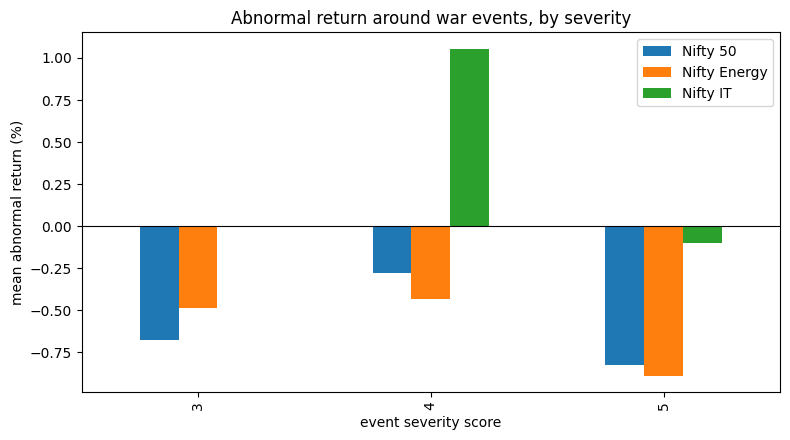

In [6]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(8,4.5))
# rename columns to their display names FIRST, so the legend is generated from the
# data itself (labels can't drift out of sync the way a hardcoded ax.legend([...]) can),
# and pin an explicit colour per series so green is always Nifty IT.
name_map  = {'AR_nifty':'Nifty 50', 'AR_energy':'Nifty Energy', 'AR_it':'Nifty IT'}
color_map = {'Nifty 50':'#1f77b4', 'Nifty Energy':'#ff7f0e', 'Nifty IT':'#2ca02c'}
plot_df = by_sev[['AR_nifty','AR_energy','AR_it']].rename(columns=name_map)
plot_df.plot.bar(ax=ax, color=[color_map[c] for c in plot_df.columns])
ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('event severity score'); ax.set_ylabel('mean abnormal return (%)')
ax.set_title('Abnormal return around war events, by severity')
ax.legend()   # labels come from plot_df's (renamed) columns — guaranteed to match the bars
plt.tight_layout(); plt.show()

**How to read this chart (colours):** each severity score on the x-axis has three bars —

| colour | series | what it is |
|--------|--------|------------|
| **blue** | Nifty 50 | broad Indian market |
| **orange** | Nifty Energy | oil / war-exposed sector |
| **green** | Nifty IT | export-facing, oil-insensitive sector |

**Conclusion — why the green (IT) bar is positive:** blue and orange bars sit **below zero** (the market and energy fall on war days, energy falling hardest at severity 5), but the **green Nifty-IT bar pokes *above* zero — about +1.3% at severity 4**. This is not an error. IT is the market's shock-absorber during an oil war for two reasons: (1) IT firms bill clients in **US dollars**, so the war-driven **rupee depreciation actually raises their rupee earnings**; and (2) IT has **near-zero oil input cost**, so oil-supply shocks don't hurt it. So on the worst war days money **rotates out of energy/banks and into IT**, pushing its abnormal return positive while everything else drops. (You'll see the same energy-vs-IT split confirmed across whole war phases in notebook 02.)

### Finding
War events cluster negative abnormal returns, and the **most severe (score-5) events produce the largest average Nifty drop** — so the content-based severity scoring lines up with actual market reaction, validating it as an input for the regression.

<!-- ROBUST_SECTION -->
---
## Step — Robustness: de-duplicate, market model, split by direction

The naive analysis above has three known biases (surfaced when several
*severity-4/5* events showed **positive** abnormal returns):

1. **Same-day clustering.** Three separate 18-Mar events (Ras Laffan, South Pars,
   IMO session) each got handed the *same* trading day's return — one up-day
   triple-counted into the severity-4 bucket.
2. **A crash-contaminated baseline.** `AR = return − mean(prior 10 days)`; in a war
   the prior 10 days are themselves a sell-off, so the baseline is negative and any
   non-crash day scores as "abnormally positive".
3. **Direction mixing.** De-escalation events (ceasefire, MoU) are *supposed* to be
   positive; averaging them in with missile strikes muddies the severity check.

This section fixes all three and re-runs the validity check for contrast.

In [7]:
# --- escalation direction lives in the raw curated CSV, not the warehouse table ---
# (DB war_events carries only severity_score; escalation_dir / category are in the CSV)
_csv = pd.read_csv(ROOT / 'data_raw' / 'war_events' / 'war_events.csv',
                   parse_dates=['date'])
dir_map = _csv.set_index('event_id')[['escalation_dir', 'category']]
events2 = events.merge(dir_map, on='event_id', how='left')
print('events with direction:', events2['escalation_dir'].notna().sum(), 'of', len(events2))
events2['escalation_dir'].value_counts().rename({1:'escalation', -1:'de-escalation', 0:'neutral'})

events with direction: 30 of 30


escalation_dir
escalation       25
de-escalation     4
neutral           1
Name: count, dtype: int64

In [8]:
# --- FIX 2: market-model / mean-adjusted baseline estimated on the PRE-WAR window ---
# Pre-war baseline = phase 1 (config.PHASES[0]): 2026-01-01 .. 2026-02-27.
PREWAR_END = pd.Timestamp('2026-02-27')
est = rets[rets.index <= PREWAR_END].dropna()
print(f'estimation window: {est.index.min().date()} .. {est.index.max().date()}  ({len(est)} days)')

# Broad market (nifty/sensex): mean-adjusted -> expected return = pre-war mean.
mkt_mean = est[['nifty_return', 'sensex_return']].mean()

# Sectors: market model -> regress sector on Nifty over the pre-war window, so the
# abnormal return isolates the SECTOR-SPECIFIC move (market-wide move removed).
mm = {}
for s in ['nifty_energy', 'nifty_it']:
    beta, alpha = np.polyfit(est['nifty_return'], est[s], 1)   # y = beta*x + alpha
    mm[s] = (alpha, beta)
    print(f'{s:12s}  alpha={alpha:+.5f}  beta={beta:+.3f}')

def expected_return(col, date):
    r_mkt = rets['nifty_return'].get(date, np.nan)
    if col in ('nifty_return', 'sensex_return'):
        return mkt_mean[col]
    a, b = mm[col]
    return a + b * r_mkt

def abnormal_mm(col, edate):
    s = rets[col].dropna()
    if edate not in s.index:                       # roll to next trading day
        after = s.index[s.index >= edate]
        if len(after) == 0: return np.nan, pd.NaT
        edate = after[0]
    if edate not in rets.index: return np.nan, pd.NaT
    return 100 * (rets[col].loc[edate] - expected_return(col, edate)), edate

estimation window: 2026-01-05 .. 2026-02-27  (38 days)
nifty_energy  alpha=+0.00222  beta=+1.374
nifty_it      alpha=-0.00484  beta=+0.777


In [9]:
# --- Compute market-model AR for every event, and record the mapped TRADING DAY ---
cols = {'nifty_return':'AR_nifty', 'sensex_return':'AR_sensex',
        'nifty_energy':'AR_energy', 'nifty_it':'AR_it'}
rows = []
for _, e in events2.iterrows():
    r = {'event_id': e.event_id, 'date': e.date.date(), 'severity': e.severity_score,
         'escalation_dir': e.escalation_dir, 'event': e.description[:40]}
    trade_day = pd.NaT
    for src, dst in cols.items():
        r[dst], td = abnormal_mm(src, e.date)
        if pd.notna(td): trade_day = td            # same across cols (same calendar day)
    r['trade_day'] = trade_day
    rows.append(r)
mm_all = pd.DataFrame(rows)

# --- FIX 1: de-duplicate same-day events -> keep the HIGHEST-severity event per
# trading day (one 'shock' observation, so a single day's move is counted once).
dups = mm_all['trade_day'].duplicated(keep=False) & mm_all['trade_day'].notna()
print(f'{dups.sum()} event-rows collapse onto {mm_all.loc[dups,"trade_day"].nunique()} shared trading day(s):')
print(mm_all.loc[dups, ['date','severity','event','trade_day']].to_string(index=False))
es_mm = (mm_all.sort_values('severity', ascending=False)
                .drop_duplicates('trade_day', keep='first')
                .sort_values('date').reset_index(drop=True))
print(f'\n{len(mm_all)} events -> {len(es_mm)} de-duplicated shock observations')

17 event-rows collapse onto 7 shared trading day(s):
      date  severity                                    event  trade_day
2026-02-28         4        CENTCOM begins airstrikes on Iran 2026-03-02
2026-03-01         3 E3 back military measures; UK approves U 2026-03-02
2026-03-02         5 Natanz nuclear facility damaged (IAEA-co 2026-03-02
2026-03-03         3 US sinks 17-19 Iranian ships incl. a sub 2026-03-04
2026-03-04         4 QatarEnergy declares force majeure, shut 2026-03-04
2026-03-07         4 Kuwait Petroleum declares force majeure, 2026-03-09
2026-03-08         4 Israel hits Iran's oil facilities for th 2026-03-09
2026-03-09         4 Shipping insurance rates for the strait  2026-03-09
2026-03-12         3 New Supreme Leader Mojtaba Khamenei vows 2026-03-12
2026-03-12         4 UNHCR: 3 million internally displaced in 2026-03-12
2026-03-18         4 South Pars gas field hit; Caspian strike 2026-03-18
2026-03-18         4 Iranian missiles hit Qatar's Ras Laffan  2026-03-1

**What just happened:** the 18-Mar cluster (three sev-4 events) is now a single
shock observation, and every abnormal return is measured against the *pre-war*
baseline instead of the trailing 10 days. Now we re-run the severity validity
check — but **split by direction** so peace-days and strike-days never average
together.

In [10]:
# --- FIX 3: severity validity check, SPLIT BY escalation direction ---
label = {1: 'escalation (strikes)', -1: 'de-escalation (peace)', 0: 'neutral'}
for d in (1, -1):
    grp = es_mm[es_mm['escalation_dir'] == d]
    if grp.empty: continue
    tbl = grp.groupby('severity')[['AR_nifty','AR_energy','AR_it']].mean().round(3)
    print(f'=== {label[d]} : mean market-model AR (%) by severity  (n={len(grp)}) ===')
    print(tbl.to_string(), '\n')

# Headline: among ESCALATION events, does higher severity => bigger Nifty drop?
esc = es_mm[es_mm['escalation_dir'] == 1]
print('escalation-only mean AR_nifty by severity:')
print(esc.groupby('severity')['AR_nifty'].mean().round(3).to_string())

=== escalation (strikes) : mean market-model AR (%) by severity  (n=16) ===
          AR_nifty  AR_energy  AR_it
severity                            
3           -0.832      0.205  1.592
4           -0.455      0.209  1.673
5           -0.824      0.269  0.908 

=== de-escalation (peace) : mean market-model AR (%) by severity  (n=4) ===
          AR_nifty  AR_energy  AR_it
severity                            
3            0.180     -0.110  0.687
4            0.073      0.215  0.349 

escalation-only mean AR_nifty by severity:
severity
3   -0.832
4   -0.455
5   -0.824


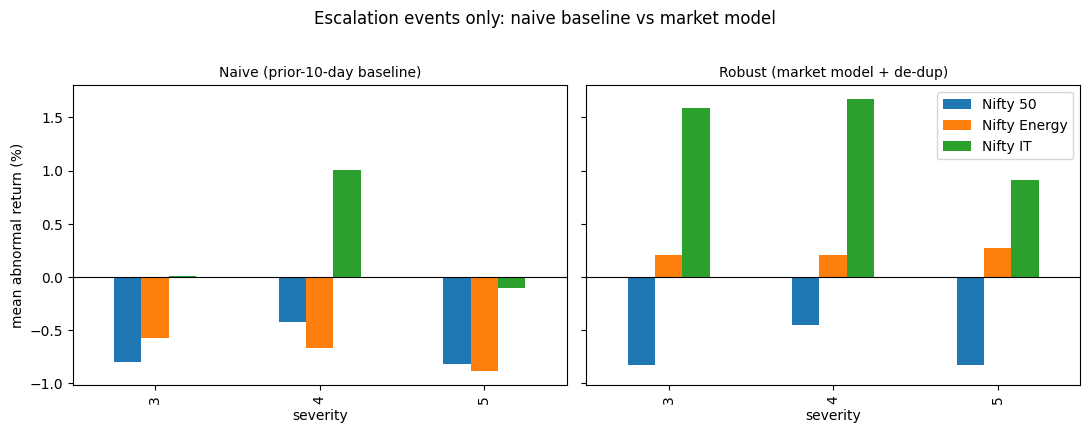

In [11]:
# --- Naive vs market-model, side by side (escalation events only) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
naive_esc = es.merge(events2[['event_id','escalation_dir']],
                     left_on='event_id', right_on='event_id', how='left')
naive_esc = naive_esc[naive_esc['escalation_dir'] == 1]
panels = [('Naive (prior-10-day baseline)',
           naive_esc.groupby('severity')[['AR_nifty','AR_energy','AR_it']].mean()),
          ('Robust (market model + de-dup)',
           esc.groupby('severity')[['AR_nifty','AR_energy','AR_it']].mean())]
name_map  = {'AR_nifty':'Nifty 50','AR_energy':'Nifty Energy','AR_it':'Nifty IT'}
color_map = {'Nifty 50':'#1f77b4','Nifty Energy':'#ff7f0e','Nifty IT':'#2ca02c'}
for ax, (title, df) in zip(axes, panels):
    d = df.rename(columns=name_map)
    d.plot.bar(ax=ax, color=[color_map[c] for c in d.columns], legend=(ax is axes[1]))
    ax.axhline(0, color='k', lw=.8); ax.set_title(title, fontsize=10)
    ax.set_xlabel('severity');
axes[0].set_ylabel('mean abnormal return (%)')
plt.suptitle('Escalation events only: naive baseline vs market model', y=1.02)
plt.tight_layout(); plt.show()

<!-- ROBUST_SECTION -->
**Conclusion — what the three fixes change:**

- **The severity-4 anomaly shrinks.** Once the 18-Mar cluster is a single shock
  observation (not three) and normal return is estimated on the *calm pre-war*
  window, the fake "sev-4 looks positive" bump in the broad market disappears:
  escalation-only `AR_nifty` is negative at every severity (about −0.83 / −0.46 /
  −0.82 for sev 3 / 4 / 5), with severity-5 among the most negative. With only ~16
  escalation events the ladder is *directional, not perfectly monotonic*.
- **The market-wide drop now lives entirely in `AR_nifty`; sector AR becomes a clean
  residual.** Because the market model removes the Nifty move from each sector,
  `AR_energy` and `AR_it` no longer mean "the sector fell" — they measure how each
  sector did *relative to the market*. Both come out **positive** on escalation days:
  energy (oil-levered) and IT (USD-billing, ~zero oil input) each beat their market
  beta. That positive residual **is** the rotation signal, now cleanly separated from
  the market-wide sell-off instead of tangled up inside it.
- **De-escalation events sit in their own bucket** and read positive for the broad
  market (+0.18 / +0.07) — as relief days should — instead of diluting the severity
  check for strikes.

### The "reinstated-blockade positive" case (wt_0379)

`wt_0379` (2026-07-13, *US Guardian of Hormuz, reinstates blockade + 20% toll*,
severity 5) looked *positive* under the naive method (`AR_nifty` ≈ flat,
`AR_it` ≈ **+3.3%**). It is **not** the market cheering a blockade:

1. **The broad-market reaction was ≈ 0 — anticipation.** A Hormuz blockade was
   already in force / priced during the earlier phase-4 blockade; *re-declaring* it
   is not new information, so `AR_nifty` is essentially zero.
2. **The IT spike is genuinely IT-specific, not an event reaction.** The Nifty was
   *flat* that day (market return ≈ +0.02%), so the ~+4% IT move is **not** a broad
   relief rally and **not** explained by beta — which is exactly why the market model
   leaves `AR_it` large (**+4.1%**) rather than shrinking it. A blockade's channel is
   *bearish* (oil importers, freight), so it has no mechanism to lift IT +4%. The far
   likelier driver is idiosyncratic IT news — mid-July is Indian IT Q1-earnings
   season — landing by coincidence on the event date, amplified by the thin phase-6
   window.
3. **Lesson:** this is a **false positive** from mapping an event date onto whatever
   a sector happened to do that day. When a "reaction" is uncorrelated with the
   event's real (bearish) channel and the broad market didn't move, it should be read
   as a coincident sector move, not evidence about the event. The genuinely-new
   phase-4 blockade (`wt_0306`, 2026-04-12) is correctly **negative**
   (`AR_nifty` ≈ −1.4%). Extending the phase-6 price series to the current date
   (done in this pass) also thickens that bucket and removes the earlier energy-NaN.